In [10]:
import pandas as pd

df = pd.read_csv("../data/processed/online_retail_clean.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [11]:
print(df.shape)
df.info()

(1028001, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1028001 entries, 0 to 1028000
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1028001 non-null  str    
 1   StockCode    1028001 non-null  str    
 2   Description  1028001 non-null  str    
 3   Quantity     1028001 non-null  int64  
 4   InvoiceDate  1028001 non-null  str    
 5   Price        1028001 non-null  float64
 6   Customer ID  797885 non-null   float64
 7   Country      1028001 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 62.7 MB


In [12]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1028001 entries, 0 to 1028000
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1028001 non-null  str           
 1   StockCode    1028001 non-null  str           
 2   Description  1028001 non-null  str           
 3   Quantity     1028001 non-null  int64         
 4   InvoiceDate  1028001 non-null  datetime64[us]
 5   Price        1028001 non-null  float64       
 6   Customer ID  797885 non-null   float64       
 7   Country      1028001 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 62.7 MB


## Dataset Overview

The cleaned dataset contains **1,028,001 rows** and **8 columns**

The dataset includes transaction details such as invoice number, product information, quantity, invoice date, unit price, customer ID, and country.

The 'InvocieDate' column was converted from string to datetime format to support time-based analysis during the EDA process.

In [16]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.028001e+06,1028001,1.028001e+06,797885.000000
mean,1.050364e+01,2011-01-04 00:05:26.537542,4.636578e+00,15313.062777
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-05 14:11:00,1.250000e+00,13964.000000
50%,3.000000e+00,2010-12-09 14:09:00,2.100000e+00,15228.000000
75%,1.000000e+01,2011-07-27 15:16:00,4.150000e+00,16788.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.694978e+02,NaN,1.226965e+02,1696.466663


In [17]:
df.describe(include="str")

,Invoice,StockCode,Description,Country
count,1028001,1028001,1028001,1028001
unique,48593,4936,5485,43
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,5651,5740,943286


In [18]:
df.nunique()

Invoice        48593
StockCode       4936
Description     5485
Quantity         740
InvoiceDate    44518
Price           2807
Customer ID     5942
Country           43
dtype: int64

In [19]:
df.isnull().sum()

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    230116
Country             0
dtype: int64

## Summary Statistics

The dataset contains both numerical and categorical variables representing retail transactions.

The numerical variables include Quantity and Price, while the categorical variables incldue Invoice, StockCode, Description, Customer ID, and Country.

Summary statistics provide and initial understanding of the data distribution before visual exploration. 

## Summary Statistics

The cleand dataset contains **1,028,001 transactions**, **5,942 unique customers**, and **43 countries**.

Most transactions originated fromn the **United Kingdom**, indicating that the dataset is heavily concentrated in one market.

The Quantity and Price variables contain extreme values, suggesting the presence of wholesale purchases, returns, or data adjuistments.

Approximately **230,000 records** have missing Customer IDs, which should be considered when performing customer-level analyses such as RFM segmentation.

In [20]:
negative_qty = df[df["Quantity"] <0]

negative_qty.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [21]:
negative_qty.shape

(19103, 8)

In [22]:
negative_price = df[df["Price"] <0]

negative_price.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
175951,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
270801,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
396041,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
789631,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
789632,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [23]:
negative_price.shape

(5, 8)

In [24]:
zero_price = df[df["Price"] == 0]
zero_price.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4595,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
5821,489861,DOT,DOTCOM POSTAGE,1,2009-12-02 14:50:00,0.0,NaN,United Kingdom
6685,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
15870,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18490,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18491,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
31556,491971,85042,ANTIQUE LILY FAIRY LIGHTS,1,2009-12-14 18:37:00,0.0,NaN,United Kingdom
32463,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
39540,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
46321,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom


In [25]:
zero_price.shape

(979, 8)

In [28]:
negative_qty[["Invoice","Description", "Quantity", "Price"]].head(20)

,Invoice,Description,Quantity,Price
178,C489449,PAPER BUNTING WHITE LACE,-12,2.95
179,C489449,CREAM FELT EASTER EGG BASKET,-6,1.65
180,C489449,POTTING SHED SOW 'N' GROW SET,-4,4.25
181,C489449,POTTING SHED TWINE,-6,2.10
182,C489449,PAPER CHAIN KIT RETRO SPOT,-12,2.95
183,C489449,SAVE THE PLANET MUG,-12,1.25
184,C489449,ANTIQUE SILVER TEA GLASS ETCHED,-12,1.25
185,C489449,HANGING HEART ZINC T-LIGHT HOLDER,-24,0.85
186,C489449,PAPER BUNTING RETRO SPOTS,-12,2.95
196,C489459,PURPLE SWEETHEART BRACELET,-3,4.25


## Investigation of Negative and Zero Values

Before performing visual analysis, negative and zero values were investigated to determine whether they represented data quality issues or valid business transactions.

Key findings:

- Transactions with **negative quantities** were associated with invoice numbers beginning with **C**, indicating product returns or cancellations.
- Transactions with **negative prices** were limited to five records labeled **Adjust bad debt**, representing accounting adjustments rather than retail sales.
- Transactions with **zero prices** likely represent promotional items, manual entries, or other special business cases.

These findings suggest that the negative and zero values are meaningful business events rather than simple simple data errors.

In [29]:
sales_df = df[
    (df["Quantity"] > 0) & 
    (df["Price"] >0)
].copy()

sales_df.shape

(1007914, 8)

In [30]:
print(f"Origianl dataset : {len(df):,}")
print(f"Sales dataset : {len(sales_df):,}")
print(f"Removed records :{len(df)-len(sales_df):,} ")

Origianl dataset : 1,028,001
Sales dataset : 1,007,914
Removed records :20,087 


In [31]:
print("Negative Quantity :", (sales_df["Quantity"]<0).sum())
print("Negative Price :", (sales_df["Price"]<0).sum())
print("Zero Price :", (sales_df["Price"]==0).sum())

Negative Quantity : 0
Negative Price : 0
Zero Price : 0


In [32]:
sales_df["Sales"] = sales_df["Quantity"] * sales_df["Price"]

sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## Sales Dataset Preparation

To focus on actual pruchaing behavior, a separate sales dataset was created by excluding:

- Returned transactions (Quantity ≤ 0)
- Accounting adjustment records (Price <0)
- Zero-priced transactions (Price = 0)

The original dataset was preserved, while all subsequent exploratory ananlyses were conducted using the filtered sales dataset ('Sales_df').

A new variable, **Sales**, was created by multiplying **Quantity * Price** to represent the total transaction value.


In [ ]:
# 1-1 Create Sales Columns

sales_df["Sales"] = sales_df["Quantity"] * sales_df["Price"]

In [34]:
#1-2 Sunnary Statistics

sales_df[["Quantity", "Price", "Sales"]].describe()

,Quantity,Price,Sales
count,1.007914e+06,1.007914e+06,1.007914e+06
mean,1.111717e+01,4.074618e+00,2.031585e+01
std,1.284700e+02,5.043177e+01,2.057160e+02
min,1.000000e+00,1.000000e-03,1.000000e-03
25%,1.000000e+00,1.250000e+00,4.130000e+00
50%,4.000000e+00,2.100000e+00,1.008000e+01
75%,1.200000e+01,4.130000e+00,1.770000e+01
max,8.099500e+04,2.511109e+04,1.684696e+05


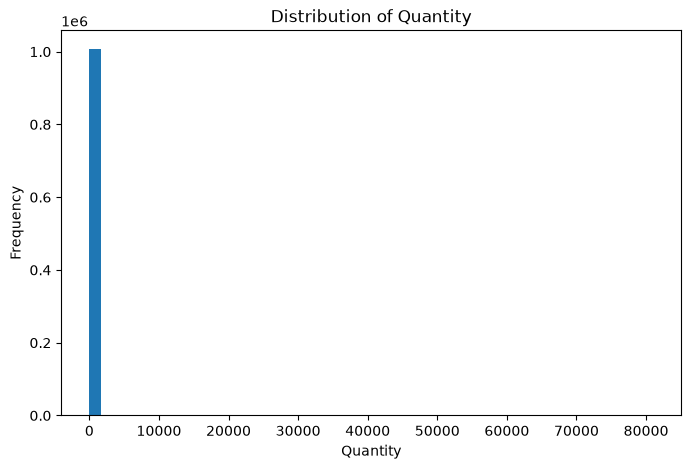

In [ ]:
#1-3-1 Quantity Histogram (50개 구간)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(sales_df["Quantity"], bins=50)

plt.title("Distribution of Quantity")

plt.xlabel("Quantity")

plt.ylabel("Frequency")

plt.show()

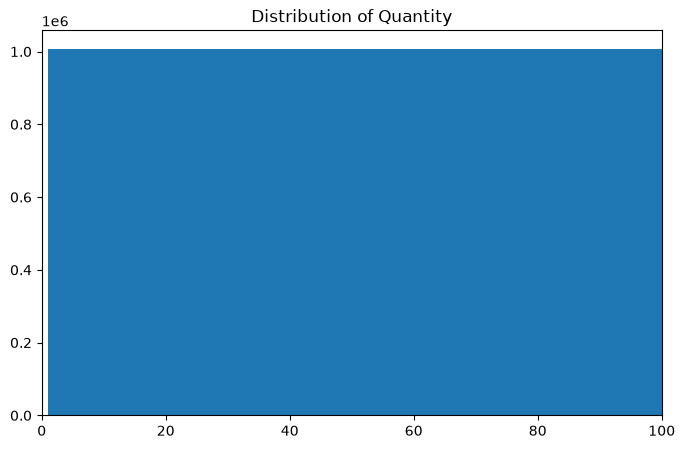

In [37]:
# 1-3-2 Quantity Histogram (X축 범위를 100까지 제한)

plt.figure(figsize=(8,5))

plt.hist(sales_df["Quantity"], bins=50)

plt.xlim(0,100)

plt.title("Distribution of Quantity")

plt.show()

## Distribution of Transaction Sales

Transaction values are highly concentrated at lower sales amounts.

Only a small proportion of transactions generate exceptionally high revenue.

## Business Insight

The majority of transactions are low-value purchases, while a relatively small number of large transactions account for a significant share of revenue. This pattern is common in retail and hightlights the importance of identifying high-value customers. 

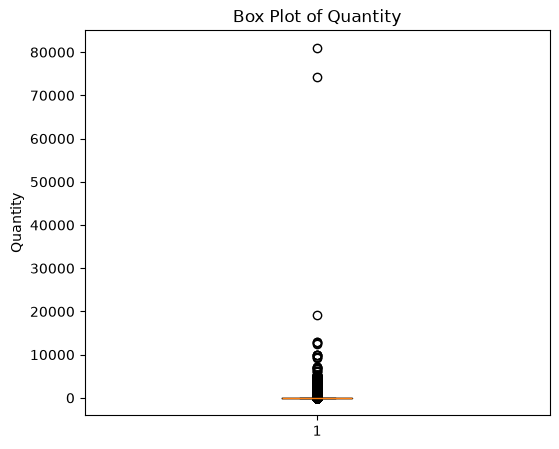

In [38]:
# 2-1 Quantity Box Plot

plt.figure(figsize=(6,5))
plt.boxplot(sales_df["Quantity"])
plt.title("Box Plot of Quantity")
plt.ylabel("Quantity")
plt.show()

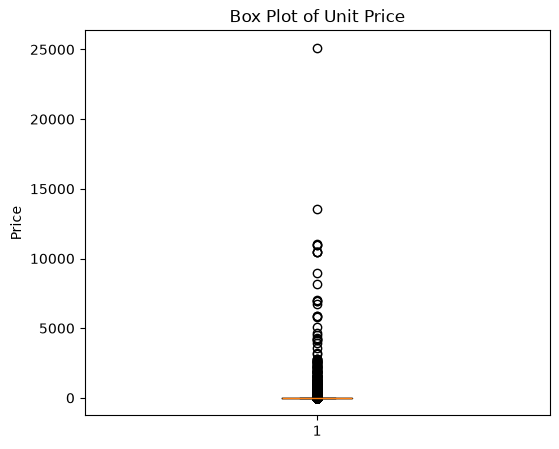

In [40]:
#2-2 Price Box Plot

plt.figure(figsize=(6,5))

plt.boxplot(sales_df["Price"])

plt.title("Box Plot of Unit Price")

plt.ylabel("Price")

plt.show()

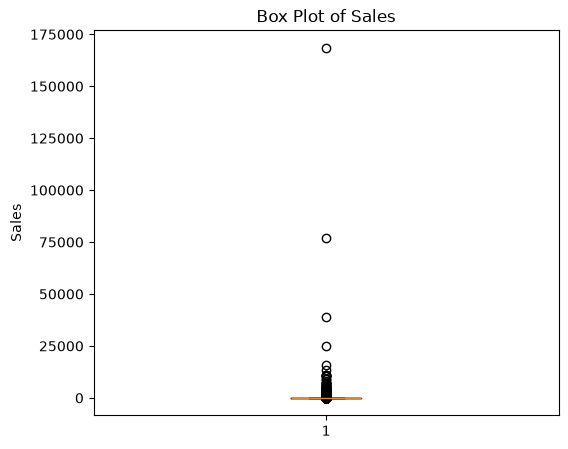

In [41]:
#2-3 Sales Box Plot

plt.figure(figsize=(6,5))

plt.boxplot(sales_df["Sales"])

plt.title("Box Plot of Sales")

plt.ylabel("Sales")

plt.show()

### Box Plot Analysis 

Box plots were used to examine the distribution of Quantity, Price, and Sales while identifying protential outliers.

All three variables exhibit strong right-skewed distributions with numerous observations beyond the upper whisker. These extreme values are consistent with the histogram analysis and likely represent meaningful business events such as bulk purchases, premium-priced products, or high-value customer transactions rather than data errors. 

In [ ]:
# 2-4 Outlier Investigation: Sales

sales_df.nlargest(10, "Sales")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
1026519,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
554116,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
713089,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
236866,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,25111.09
424077,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,15818.40
507980,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33
789630,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06
132260,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,10953.50
132262,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,10953.50
335624,522796,M,Manual,1,2010-09-16 15:12:00,10468.80,NaN,United Kingdom,10468.80


In [43]:
# 2-4 Outlier Investigation: Quantity

sales_df.nlargest(10, "Quantity")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
1026519,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6
554116,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6
89033,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902.0,Denmark,1915.2
124582,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,1296.0
124584,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,1296.0
124585,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,13902.0,Denmark,1274.4
124583,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,13902.0,Denmark,1248.0
132274,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.0
132275,502269,21982,PACK OF 12 SUKI TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.0
132276,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.0


In [44]:
# 2-4 Outlier Investigation: Price
sales_df.nlargest(10, "Price") 

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
236866,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,25111.09
507980,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33
789630,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06
132260,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,10953.50
132262,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,10953.50
335624,522796,M,Manual,1,2010-09-16 15:12:00,10468.80,NaN,United Kingdom,10468.80
351868,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,10468.80
365860,525399,M,Manual,1,2010-10-05 11:49:00,10468.80,NaN,United Kingdom,10468.80
73095,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949.0,United Kingdom,8985.60
664336,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75


### Outlier Investigation

The largest Quantity transactions were associated with bulk purchases, suggesting legitimate wholesales or business orders.

The highest Price observations primarily consisted of manual adjustments, administrative charges, and accounting-related records such as "Manual", "AMAZON FEE", and "Adjust bad debt".

The highest Sales transactions were mainly driven by extremely large purchase quantities rather than usually expensive products.

These findings indicate that not all outliers should be treated as data errors. Instead, they represent different business scenarios that should be analyzed separately.

In [ ]:
# 3-1. Daily Sales Trend 
# 1) Create Date column

sales_df["Date"] = sales_df["InvoiceDate"].dt.date

In [ ]:
# 2) Calculte Daily Sales

daily_sales = (
    sales_df
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Date,Sales
0,2009-12-01,54351.23
1,2009-12-02,63172.58
2,2009-12-03,73972.45
3,2009-12-04,40582.32
4,2009-12-05,9803.05


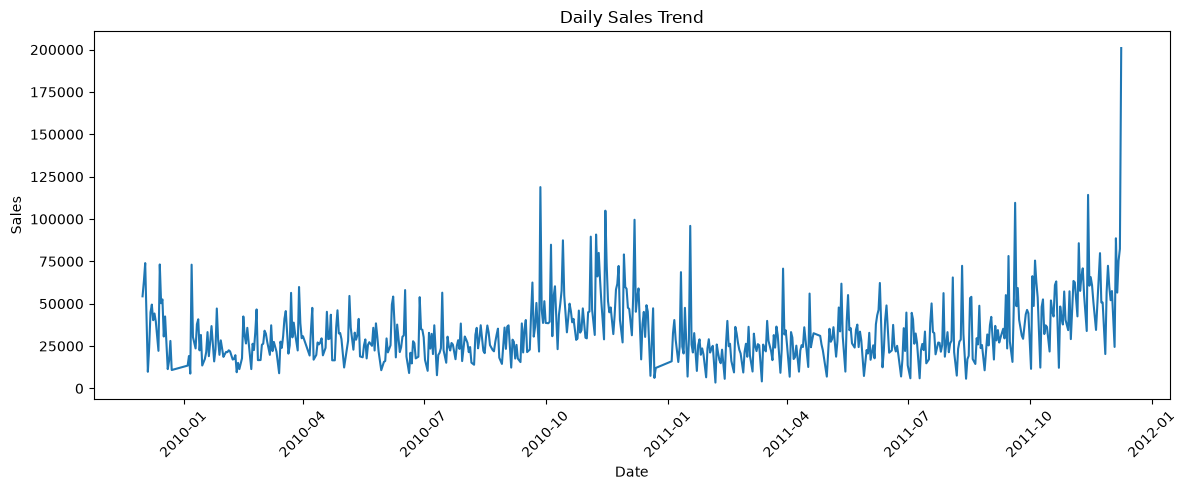

In [ ]:
# 3) Create Line Chart of Daily Sales
plt.figure(figsize=(12,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"]
)

plt.title ("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Daily Sales Trend

Daily sales were aggreated to examine overall revenue trends over time.

The line chart provides and overview of fluctuations in daily sales and helps identify periods of unusually high or low sales activity. 

Daily sales fluctuate substantially throughtout the observation period.

Despite the high day-to-day variability, the overall trend suggests increasing sales toward the end of 2011.

A pronounced sales spike is observed near the end of the dataset, which is consistent with the bulk purchase transactions identified during the outlier investigation. 

The daily trend also indicates a possbile seasonal increase in sales during the final months of the year.

In [48]:
# 3-2 Montly Sales Trend
# 1) Create Month Column

sales_df["Month"]= sales_df["InvoiceDate"].dt.to_period("M")

In [49]:
# 2) Aggregate Monthly Sales

monthly_sales = (
    sales_df
    .groupby("Month")["Sales"]
    .sum()
    .reset_index()
)

In [ ]:
#3) Convert formatting 

monthly_sales["Month"] = monthly_sales["Month"].astype(str)

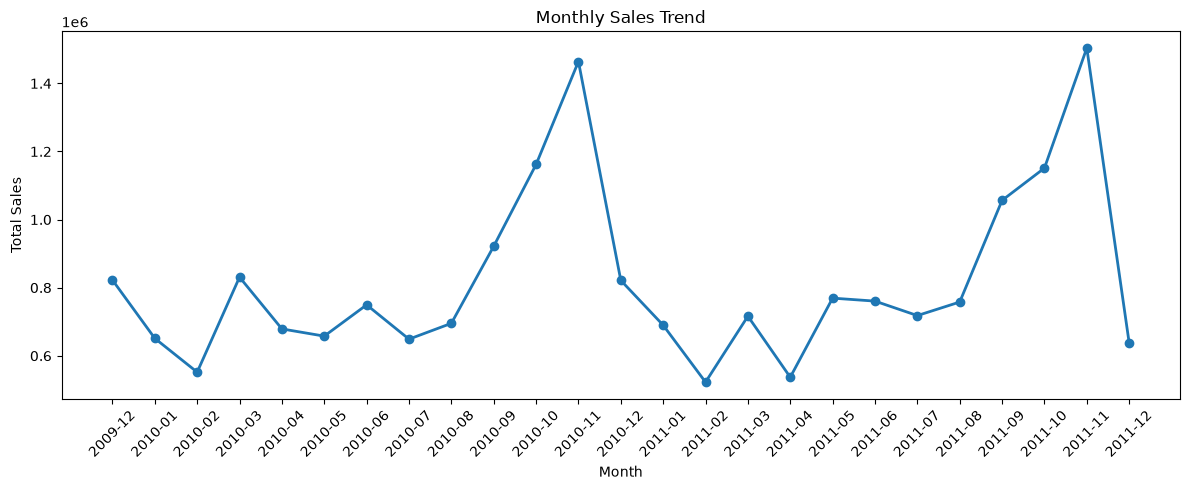

In [52]:
# 4) Montly Sales Trend

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Monthly Sales Trend

Monthly sales reveal a consistent seasonal pattern across both years.

Sales begin to increase around September and reach their highest levels in November, suggesting strong year-end demand.

In addition, overall sales in 2011 are generally higher than those in 2010, indicating continued business growth.

It should be noted that December 2011 contains only partitial-month data, and therefore should not be interpreted as a declind in business performance.


In [54]:
# 3-3 Monthly Order Count

monthly_orders = (
    sales_df
    .groupby("Month")["Invoice"]
    .nunique()
    .reset_index(name="Order Count")
    )

monthly_orders["Month"] = monthly_orders["Month"].astype(str)

monthly_orders.head()

,Month,Order Count
0,2009-12,1682
1,2010-01,1105
2,2010-02,1202
3,2010-03,1681
4,2010-04,1462


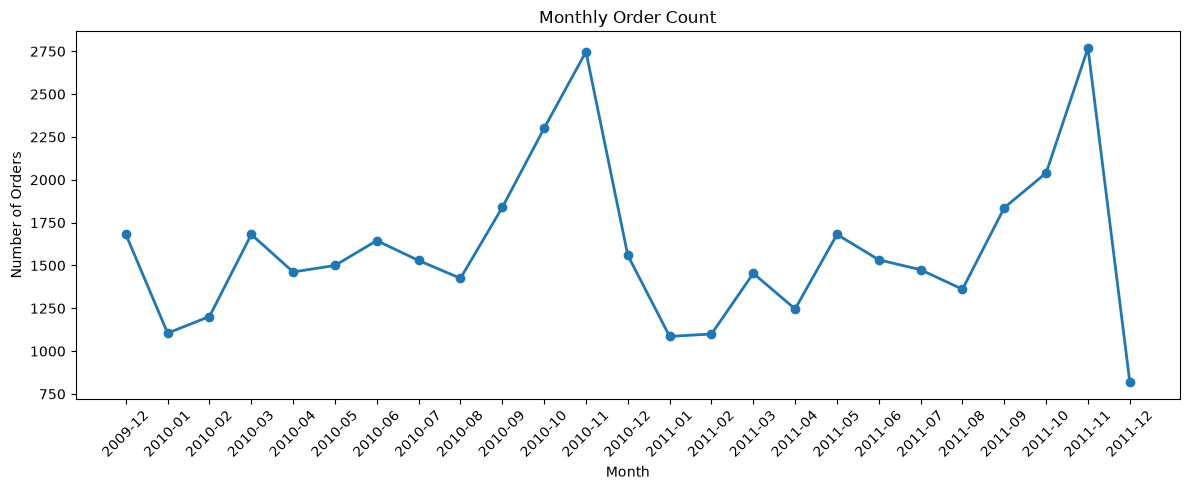

In [56]:
# 3-3 Monthly order chart

plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders["Month"],
    monthly_orders["Order Count"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Order Count")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Monthly Order Count

Monthly order counts were caculated to determined whether changes in sales were driven by fluctuations in the number of customer orders.

Tracking order volume helps distinguish between revenue growth resulting from increased purchasing activity and growth driven by higher transaction values.

In [57]:
# 3-4 Monthly Active Customers 

monthly_customers = (
    sales_df
    .dropna(subset=["Customer ID"])
    .groupby("Month")["Customer ID"]
    .nunique()
    .reset_index(name="Active Customer")
)

monthly_customers["Month"] = monthly_customers["Month"].astype(str)

monthly_customers.head()

,Month,Active Customer
0,2009-12,955
1,2010-01,720
2,2010-02,772
3,2010-03,1057
4,2010-04,942


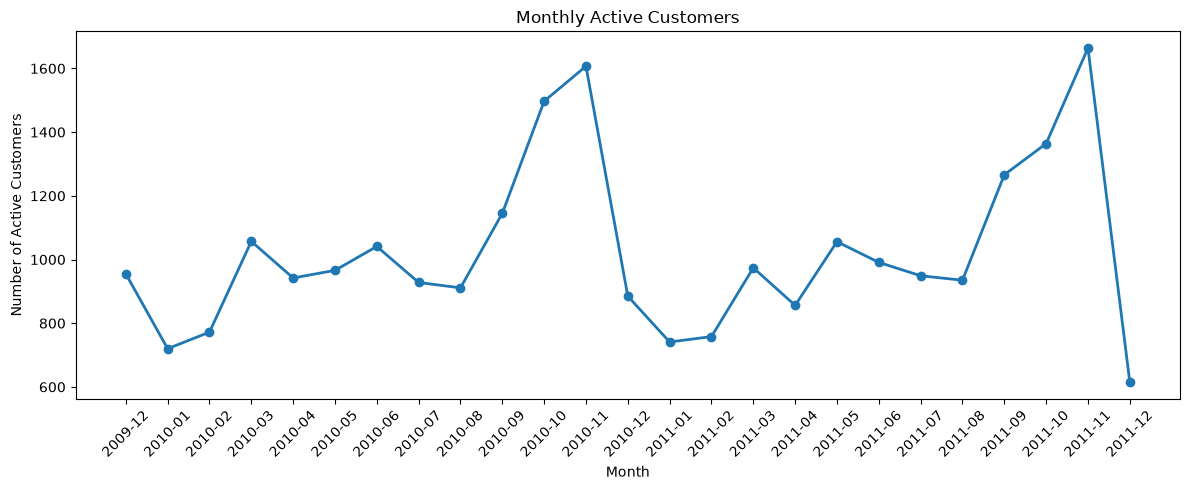

In [62]:
# 3-4 Monthly Active Customer Chart

plt.figure(figsize=(12,5))

plt.plot(
    monthly_customers["Month"],
    monthly_customers["Active Customer"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Active Customers")

plt.xlabel("Month")

plt.ylabel("Number of Active Customers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Monthly Active Customers

Monthly active customers were measured using unique customer IDs.

This analysis helps determine whether revenue growth is associated with acquiring more customers or changes in customer purchasing behavior.

### Monthly Business Performance

Monthly Sales, Monthly Order Count, and Monthly Active Customers exibit highly consistent trends throughout the observation period.

All three metrics increase substially from September and reach their highest levels in November, suggesting a strong seasonal shopping pattern.

Furthermore, the simultaneous growth of customers, orders, and revenue indicates that business growth is driven by expanding customer activity rather than a small number of exceptional transactions. 

December 2011 contains only partial-month data and should therefore not be interpreted as a decline in business performance.
